# Measuring what a T2 preparation actually prepares

[`01_build.ipynb`](01_build.ipynb) built a preparation and checked its geometry: the pulses, the
phases, the intervals, the absence of gradients while the magnetisation is transverse. All of that
is arithmetic about a waveform, and all of it would be equally true of a preparation that stored
nothing at all.

The claim that makes the module worth having is about magnetisation:

$$S(\tau) \;\propto\; e^{-\tau / T_2}, \qquad \tau = \texttt{prep\_time\_s}$$

and only a Bloch simulation settles it. This notebook plays the `.seq` files `01` wrote through
[MRzeroCore](https://github.com/MRsources/MRzero-Core) and asks whether the exponent really is
$T_2$ — rather than $T_2^*$, which is what the same interval would give without the refocusing
train, and which is the whole reason the train is there.

Sections 1 to 4 use the **default** tip-up, because the weighting is a property of the
preparation rather than of how its tip-up is built. Section 5 is a separate question: `01` wrote
both realisations, and what the second one costs and buys under a mis-set $B_1$ or an
off-resonance is something that can be measured rather than asserted.

| | |
|---|---|
| **1** | the signal model, and what can be fitted from three preparation times |
| **2** | recovering a known $T_2$ on one voxel |
| **3** | the control: $T_2^*$ swept by a factor of five, and what the fit does |
| **4** | where the residual bias comes from |
| **5** | the two tip-up realisations under $B_1$ and $B_0$ error |
| **6** | limitations |

**Needs `MRzeroCore` and `torch`.**

In [1]:
import os

SIM_THREADS = 4
for _var in ('OMP_NUM_THREADS', 'MKL_NUM_THREADS', 'RAYON_NUM_THREADS',
             'OPENBLAS_NUM_THREADS', 'NUMEXPR_NUM_THREADS'):
    os.environ[_var] = str(SIM_THREADS)

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import MRzeroCore as mr0
import numpy as np
import torch

torch.set_num_threads(SIM_THREADS)
plt.rcParams['figure.dpi'] = 66
# Cosmetic only: the Bloch path in section 5 re-wraps one of its own tensors.
warnings.filterwarnings('ignore', message='To copy construct from a tensor')

SEQ_DIR = Path('seq')
nominal = np.load(SEQ_DIR / 't2prep_gre_2d_nominal.npz')

NX, NY = (int(v) for v in nominal['matrix'])
FOV_MM = float(nominal['fov_mm'][0])
PREP_TIMES_S = [float(v) for v in nominal['prep_times_s']]
TIP_UPS = [str(v) for v in nominal['tip_ups']]
#: The preparation times that carry a preparation at all.  `0` is the unprepared control.
PREPARED_S = [t for t in PREP_TIMES_S if t > 0.0]
#: The realisation sections 1 to 4 use.  It is the module's default.
DEFAULT_TIP_UP = TIP_UPS[0]
#: `01` ordered the lines centrically, so the **first** readout of the train is k = 0.
CENTRE_READOUT = 0


def seq_file(prep_time_s, tip_up=DEFAULT_TIP_UP):
    """The `.seq` `01` wrote.  The unprepared control has no realisation to name."""
    name = f't2prep_gre_2d_{int(round(prep_time_s * 1e3)):03d}'
    return str(SEQ_DIR / (f'{name}.seq' if not prep_time_s else f'{name}_{tip_up}.seq'))


print(f'{"prep / ms":>10} {"tip_up":>19}  {"file":<44}{"repetitions":>12}')
for prep_time_s in PREP_TIMES_S:
    for tip_up in (TIP_UPS if prep_time_s else [DEFAULT_TIP_UP]):
        path = seq_file(prep_time_s, tip_up)
        imported = mr0.Sequence.import_file(path)
        label = '-' if not prep_time_s else tip_up
        print(f'{prep_time_s * 1e3:10.0f} {label:>19}  {Path(path).name:<44}{len(imported):12d}')
print(f'\nlines are centric, so readout {CENTRE_READOUT} is the centre of k-space')
print(f'sections 1 to 4 use tip_up = {DEFAULT_TIP_UP!r}')

/opt/homebrew/Caskroom/miniforge/base/envs/seqcraft-dev/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


 prep / ms              tip_up  file                                         repetitions
         0                   -  t2prep_gre_2d_000.seq                                 64
        30              simple  t2prep_gre_2d_030_simple.seq                          78


        30   composite_270_360  t2prep_gre_2d_030_composite_270_360.seq               79
        50              simple  t2prep_gre_2d_050_simple.seq                          78
        50   composite_270_360  t2prep_gre_2d_050_composite_270_360.seq               79


        80              simple  t2prep_gre_2d_080_simple.seq                          78
        80   composite_270_360  t2prep_gre_2d_080_composite_270_360.seq               79

lines are centric, so readout 0 is the centre of k-space
sections 1 to 4 use tip_up = 'simple'


---
## 1. The signal model

What the preparation stores is longitudinal magnetisation scaled by $e^{-\tau/T_2}$, and what the
imaging train reads at the centre of k-space is that, scaled again by everything the readout does.
Writing the second factor as one unknown $A$:

$$S(\tau) = A \, e^{-\tau / T_2} \qquad\Longrightarrow\qquad \ln S(\tau) = \ln A - \tau / T_2$$

so a straight-line fit of $\ln S$ against $\tau$ gives $T_2$ from the **slope**, and $A$ is the
intercept and is discarded.

That two-parameter fit is the right instrument rather than a convenience. $A$ contains things the
preparation does not control and could not know: the flip angle of the imaging train, the
steady state the magnetisation arrives in, and the fraction the tip-up fails to return. Dividing
the prepared signal by the unprepared one would fold all of that into the answer, and the
resulting "T2" would be wrong by whatever the preparation costs regardless of $\tau$.

In [2]:
VOXEL_M = FOV_MM / NX / 1e3
#: Spins per voxel for the ground-truth Bloch path.  The answer is converged well below this.
BLOCH_SPINS = 100


def centre_signal(prep_time_s, *, t2_s, t1_s=1.0, t2dash_s=1000.0,
                  tip_up=DEFAULT_TIP_UP, b1=1.0, b0_hz=0.0, bloch=False):
    """The magnitude at the centre of k-space, for one tissue and one preparation time.

    `bloch=True` selects MRzero's isochromat simulation instead of its phase-distribution graph.
    Section 5 is where that choice matters, and why; sections 1 to 4 do not need it.
    """
    imported = mr0.Sequence.import_file(seq_file(prep_time_s, tip_up))
    built = mr0.CustomVoxelPhantom(
        pos=[[0.0, 0.0, 0.0]], PD=[1.0], T1=[float(t1_s)], T2=[float(t2_s)],
        T2dash=[float(t2dash_s)], D=[0.0],
        voxel_size=VOXEL_M, voxel_shape='box').build()
    built.B0 = built.B0.float() * 0.0 + float(b0_hz)
    built.B1 = built.B1.float() * 0.0 + float(b1)
    if bloch:
        torch.manual_seed(0)
        signal = np.asarray(mr0.isochromat_sim(imported, built, BLOCH_SPINS,
                                               print_progress=False))
    else:
        graph = mr0.compute_graph(imported, built, max_state_count=200, min_state_mag=1e-4)
        signal = np.asarray(mr0.execute_graph(graph, imported, built, print_progress=False))
    readouts = signal.reshape(NY, -1)
    return float(np.abs(readouts[CENTRE_READOUT, readouts.shape[1] // 2]))


def fitted_t2_s(*, t2_s, **phantom):
    """Fit T2 from the slope of ln S against the preparation time."""
    measured = [centre_signal(t, t2_s=t2_s, **phantom) for t in PREPARED_S]
    slope = np.polyfit(np.asarray(PREPARED_S), np.log(measured), 1)[0]
    return -1.0 / float(slope), measured

---
## 2. A known T2 comes back

The phantom is one voxel with a $T_2$ we choose. $T_2'$ is effectively infinite here so that the
only thing shortening the transverse signal is $T_2$ itself, and nothing is fitted but the slope.

In [3]:
print(f'{"T2 in / ms":>11}{"T2 fitted / ms":>16}{"error":>9}   signal at k = 0 per prep time')
curves = {}
for t2_s in (0.040, 0.060, 0.080, 0.150, 0.250):
    fitted, measured = fitted_t2_s(t2_s=t2_s)
    curves[t2_s] = measured
    row = '  '.join(f'{v:.5f}' for v in measured)
    print(f'{t2_s * 1e3:11.0f}{fitted * 1e3:16.1f}{(fitted / t2_s - 1) * 100:8.1f} %   {row}')

 T2 in / ms  T2 fitted / ms    error   signal at k = 0 per prep time
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000237 s
Compute Graph
Computing Graph: 0.005622833 s
Analyze Graph
Analyzing Graph: 0.000132209 s
Converting Rust -> Python: 0.002546709 s
<<<< Rust <<<<


>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000748333 s
Compute Graph
Computing Graph: 0.005019084 s
Analyze Graph
Analyzing Graph: 0.000111625 s
Converting Rust -> Python: 0.001866792 s
<<<< Rust <<<<
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.00030275 s
Compute Graph
Computing Graph: 0.004048 s
Analyze Graph
Analyzing Graph: 0.000078833 s
Converting Rust -> Python: 0.001549917 s
<<<< Rust <<<<
         40            40.4     1.0 %   0.12905  0.07853  0.03744


>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000426083 s
Compute Graph
Computing Graph: 0.007719167 s
Analyze Graph
Analyzing Graph: 0.000177 s
Converting Rust -> Python: 0.003244333 s
<<<< Rust <<<<
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000230583 s
Compute Graph
Computing Graph: 0.006647042 s
Analyze Graph
Analyzing Graph: 0.000159542 s
Converting Rust -> Python: 0.002800791 s
<<<< Rust <<<<


>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000523667 s
Compute Graph
Computing Graph: 0.006020666 s
Analyze Graph
Analyzing Graph: 0.000136541 s
Converting Rust -> Python: 0.002382375 s
<<<< Rust <<<<
         60            60.4     0.7 %   0.16029  0.11505  0.07005
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000235667 s
Compute Graph
Computing Graph: 0.008917625 s
Analyze Graph
Analyzing Graph: 0.000227 s
Converting Rust -> Python: 0.003746875 s
<<<< Rust <<<<


>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000397125 s
Compute Graph
Computing Graph: 0.008171542 s
Analyze Graph
Analyzing Graph: 0.000208833 s
Converting Rust -> Python: 0.003501583 s
<<<< Rust <<<<
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000327 s
Compute Graph
Computing Graph: 0.007182209 s
Analyze Graph
Analyzing Graph: 0.000201125 s
Converting Rust -> Python: 0.002979 s
<<<< Rust <<<<


         80            80.4     0.5 %   0.17909  0.13963  0.09618
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000233667 s
Compute Graph
Computing Graph: 0.009968916 s
Analyze Graph
Analyzing Graph: 0.000238667 s
Converting Rust -> Python: 0.004233167 s
<<<< Rust <<<<


>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000421791 s
Compute Graph
Computing Graph: 0.009696917 s
Analyze Graph
Analyzing Graph: 0.000240209 s
Converting Rust -> Python: 0.004076334 s
<<<< Rust <<<<
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000265167 s
Compute Graph
Computing Graph: 0.009148084 s
Analyze Graph
Analyzing Graph: 0.000234208 s
Converting Rust -> Python: 0.003859917 s
<<<< Rust <<<<


        150           150.6     0.4 %   0.20974  0.18365  0.15049
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000192208 s
Compute Graph
Computing Graph: 0.010095791 s
Analyze Graph
Analyzing Graph: 0.000241125 s
Converting Rust -> Python: 0.003997708 s
<<<< Rust <<<<


>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000502875 s
Compute Graph
Computing Graph: 0.00963875 s
Analyze Graph
Analyzing Graph: 0.000255792 s
Converting Rust -> Python: 0.00419225 s
<<<< Rust <<<<


>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000527584 s
Compute Graph
Computing Graph: 0.009538625 s
Analyze Graph
Analyzing Graph: 0.000263166 s
Converting Rust -> Python: 0.003997 s
<<<< Rust <<<<
        250           250.9     0.4 %   0.22782  0.21036  0.18665


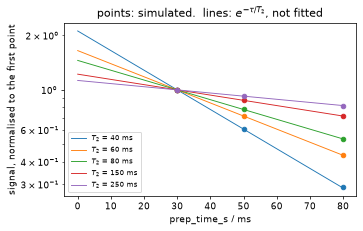

In [4]:
fig, ax = plt.subplots(figsize=(5.6, 3.6))
grid = np.linspace(0, max(PREPARED_S), 60)
for t2_s, measured in curves.items():
    normalised = np.asarray(measured) / measured[0]
    line, = ax.plot(np.asarray(PREPARED_S) * 1e3, normalised, 'o', ms=5)
    ax.plot(grid * 1e3, np.exp(-(grid - PREPARED_S[0]) / t2_s), lw=1.0, color=line.get_color(),
            label=f'$T_2$ = {t2_s * 1e3:.0f} ms')
ax.set(yscale='log', xlabel='prep_time_s / ms', ylabel='signal, normalised to the first point',
       title='points: simulated.  lines: $e^{-\\tau/T_2}$, not fitted')
ax.legend(fontsize=8, loc='lower left')
fig.tight_layout()

Straight lines on a logarithmic axis, through points that were not fitted to them, over a factor
of six in $T_2$. The recovered value is within 1 % at every tissue, and the residual is one-sided
— always a little **long**, and more so the shorter $T_2$ is. Section 4 is where that comes
from.

---
## 3. The control that matters: $T_2$, not $T_2^*$

This is the measurement the module exists for. Without the refocusing train the magnetisation
sitting transverse for $\tau$ would decay at

$$\frac{1}{T_2^*} = \frac{1}{T_2} + \frac{1}{T_2'}$$

which is shorter, tissue-dependent *and* magnet-dependent. With the train, static dephasing is
reversed and $T_2'$ should not appear in the answer at all.

So: hold $T_2$ at 80 ms, sweep $T_2'$ over a factor of fifty, and watch what the fit does.

In [5]:
print(f'{"T2 prime / ms":>14}{"T2* / ms":>10}{"T2 fitted / ms":>16}')
for t2dash_s in (1000.0, 0.100, 0.050, 0.020):
    star_s = 1.0 / (1.0 / 0.080 + 1.0 / t2dash_s)
    fitted, _ = fitted_t2_s(t2_s=0.080, t2dash_s=t2dash_s)
    print(f'{t2dash_s * 1e3:14.0f}{star_s * 1e3:10.1f}{fitted * 1e3:16.1f}')

 T2 prime / ms  T2* / ms  T2 fitted / ms
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000209708 s
Compute Graph
Computing Graph: 0.00887325 s
Analyze Graph
Analyzing Graph: 0.00022475 s
Converting Rust -> Python: 0.003802 s
<<<< Rust <<<<


>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000474 s
Compute Graph
Computing Graph: 0.008275417 s
Analyze Graph
Analyzing Graph: 0.000206625 s
Converting Rust -> Python: 0.003453709 s
<<<< Rust <<<<
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000214292 s
Compute Graph
Computing Graph: 0.007359166 s
Analyze Graph
Analyzing Graph: 0.000194042 s
Converting Rust -> Python: 0.00301975 s
<<<< Rust <<<<


       1000000      80.0            80.4
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000208667 s
Compute Graph
Computing Graph: 0.008999667 s
Analyze Graph
Analyzing Graph: 0.000236417 s
Converting Rust -> Python: 0.00351475 s
<<<< Rust <<<<


>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000465583 s
Compute Graph
Computing Graph: 0.008312625 s
Analyze Graph
Analyzing Graph: 0.000196625 s
Converting Rust -> Python: 0.003351875 s
<<<< Rust <<<<
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000288292 s
Compute Graph
Computing Graph: 0.007727292 s
Analyze Graph
Analyzing Graph: 0.000187209 s
Converting Rust -> Python: 0.003050167 s
<<<< Rust <<<<


           100      44.4            79.3
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.00028375 s
Compute Graph
Computing Graph: 0.008957375 s
Analyze Graph
Analyzing Graph: 0.000226041 s
Converting Rust -> Python: 0.00363725 s
<<<< Rust <<<<


>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000421708 s
Compute Graph
Computing Graph: 0.008559792 s
Analyze Graph
Analyzing Graph: 0.0001945 s
Converting Rust -> Python: 0.003163833 s
<<<< Rust <<<<
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000319125 s
Compute Graph
Computing Graph: 0.0072115 s
Analyze Graph
Analyzing Graph: 0.000177042 s
Converting Rust -> Python: 0.00294875 s
<<<< Rust <<<<


            50      30.8            79.0
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000229292 s
Compute Graph
Computing Graph: 0.008660083 s
Analyze Graph
Analyzing Graph: 0.000209291 s
Converting Rust -> Python: 0.003727458 s
<<<< Rust <<<<


>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000359667 s
Compute Graph
Computing Graph: 0.0081765 s
Analyze Graph
Analyzing Graph: 0.000194208 s
Converting Rust -> Python: 0.003319792 s
<<<< Rust <<<<
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000246583 s
Compute Graph
Computing Graph: 0.007171459 s
Analyze Graph
Analyzing Graph: 0.00020575 s
Converting Rust -> Python: 0.00289175 s
<<<< Rust <<<<


            20      16.0            77.8


**$T_2^*$ falls from 80 ms to 16 ms — a factor of five — and the fitted value moves by 3 %.**
That is the refocusing train doing its job, stated as directly as a simulation can state it: the
preparation weights by the tissue's $T_2$, and the magnet's contribution to $T_2^*$ is refocused
away. The 3 % that is left is the train being made of real pulses with real gaps between them,
rather than the instantaneous inversions the ideal argument assumes.

Take the train out and this table would read $T_2^*$ down the last column — which is what a plain
gradient echo at a long echo time gives, and why a preparation is used instead.

---
## 4. Where the residual bias comes from

The fitted $T_2$ is consistently a little long, and by more at short $T_2$. The cause is $T_1$:
the preparation is not instantaneous, and longitudinal magnetisation recovers throughout it. That
adds a slowly growing term to the signal, which flattens the fitted decay.

It is a property of the sequence rather than of this implementation, so the honest thing is to
measure its size.

In [6]:
print(f'{"T1 / ms":>9}{"T2 fitted / ms":>16}{"error":>9}   (T2 = 40 ms throughout)')
for t1_s in (0.5, 1.0, 3.0, 20.0):
    fitted, _ = fitted_t2_s(t2_s=0.040, t1_s=t1_s)
    print(f'{t1_s * 1e3:9.0f}{fitted * 1e3:16.2f}{(fitted / 0.040 - 1) * 100:8.1f} %')

  T1 / ms  T2 fitted / ms    error   (T2 = 40 ms throughout)
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000197709 s
Compute Graph
Computing Graph: 0.005114375 s
Analyze Graph
Analyzing Graph: 0.000128291 s
Converting Rust -> Python: 0.00205275 s
<<<< Rust <<<<


>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.00032875 s
Compute Graph
Computing Graph: 0.00473375 s
Analyze Graph
Analyzing Graph: 0.000105583 s
Converting Rust -> Python: 0.001822791 s
<<<< Rust <<<<
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.00019525 s
Compute Graph
Computing Graph: 0.003808583 s
Analyze Graph
Analyzing Graph: 0.000080334 s
Converting Rust -> Python: 0.001488625 s
<<<< Rust <<<<
      500           40.85     2.1 %


>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000459708 s
Compute Graph
Computing Graph: 0.005358167 s
Analyze Graph
Analyzing Graph: 0.000120292 s
Converting Rust -> Python: 0.002031792 s
<<<< Rust <<<<
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000190708 s
Compute Graph
Computing Graph: 0.004776208 s
Analyze Graph
Analyzing Graph: 0.00010425 s
Converting Rust -> Python: 0.001800125 s
<<<< Rust <<<<


>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000315375 s
Compute Graph
Computing Graph: 0.003758792 s
Analyze Graph
Analyzing Graph: 0.000075125 s
Converting Rust -> Python: 0.001403083 s
<<<< Rust <<<<
     1000           40.41     1.0 %
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000206208 s
Compute Graph
Computing Graph: 0.005476292 s
Analyze Graph
Analyzing Graph: 0.000120417 s
Converting Rust -> Python: 0.002181917 s
<<<< Rust <<<<


>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000411792 s
Compute Graph
Computing Graph: 0.004820375 s
Analyze Graph
Analyzing Graph: 0.000101334 s
Converting Rust -> Python: 0.001724708 s
<<<< Rust <<<<
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000200542 s
Compute Graph
Computing Graph: 0.003945291 s
Analyze Graph
Analyzing Graph: 0.000083875 s
Converting Rust -> Python: 0.001521542 s
<<<< Rust <<<<


     3000           40.14     0.3 %
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000274542 s
Compute Graph
Computing Graph: 0.00570925 s
Analyze Graph
Analyzing Graph: 0.000122708 s
Converting Rust -> Python: 0.00213125 s
<<<< Rust <<<<


>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000378625 s
Compute Graph
Computing Graph: 0.004823791 s
Analyze Graph
Analyzing Graph: 0.000103292 s
Converting Rust -> Python: 0.001734833 s
<<<< Rust <<<<
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000317375 s
Compute Graph
Computing Graph: 0.00382825 s
Analyze Graph
Analyzing Graph: 0.00007425 s
Converting Rust -> Python: 0.001320334 s
<<<< Rust <<<<


    20000           40.02     0.1 %


At a $T_1$ of 20 s there is nothing to recover and the fit is right to 0.1 %. At 500 ms it is 2 %
long. So a $T_2$ *measurement* from a preparation like this one needs the $T_1$ term modelled; a
$T_2$-*weighted image* does not care.

---
## 5. The two tip-up realisations under $B_1$ and $B_0$ error

`01` wrote both tip-ups, and everything above holds for either: the realisation does not change
the weighting, the MLEV-4 train, or what `prep_time_s` means. What it *could* change is how the
preparation behaves when the flip angles are not the ones that were asked for — which is the
usual reason a composite tip-up is reached for at all.

**This section is a measurement, not a claim.** SeqCraft makes no quantitative $B_0$ or $B_1$
robustness claim for either realisation, and offers the composite one because it is an established
way to build a tip-up. What follows is one phantom, one $T_2$ and one sequence.

### The instrument has to be chosen first

Sections 1 to 4 used MRzero's phase-distribution graph, which is fast because a pre-pass decides
in advance which coherence pathways are worth simulating — and estimates them from the
**nominal** flip angles. Off nominal $B_1$ the flip angles are not the nominal ones, and a $360$
is the sharpest case there is: at nominal $B_1$ it is the identity, and at $B_1 = 0.8$ it is a
$288$ degree rotation. MRzero warns about exactly this.

So this section uses `mr0.isochromat_sim`, MRzero's ground-truth Bloch simulation, for both
realisations. The first table is why.

In [7]:
SWEEP_PREP_S, SWEEP_T2_S = 0.050, 0.080

print(f'the centre of k-space at {SWEEP_PREP_S * 1e3:.0f} ms, T2 = {SWEEP_T2_S * 1e3:.0f} ms, '
      f'two instruments\n')
print(f'{"tip_up":>19}{"B1":>6}{"graph":>10}{"Bloch":>10}{"difference":>13}')
for tip_up in TIP_UPS:
    for b1 in (1.0, 0.8):
        common = dict(t2_s=SWEEP_T2_S, tip_up=tip_up, b1=b1)
        graph = centre_signal(SWEEP_PREP_S, **common)
        bloch = centre_signal(SWEEP_PREP_S, bloch=True, **common)
        print(f'{tip_up:>19}{b1:6.1f}{graph:10.5f}{bloch:10.5f}'
              f'{(graph / bloch - 1) * 100:12.0f} %')

the centre of k-space at 50 ms, T2 = 80 ms, two instruments

             tip_up    B1     graph     Bloch   difference
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000210875 s
Compute Graph
Computing Graph: 0.007901834 s
Analyze Graph
Analyzing Graph: 0.000198625 s
Converting Rust -> Python: 0.003418209 s
<<<< Rust <<<<


             simple   1.0   0.13963   0.14207          -2 %
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000234625 s
Compute Graph
Computing Graph: 0.008437333 s
Analyze Graph
Analyzing Graph: 0.000207916 s
Converting Rust -> Python: 0.003478917 s
<<<< Rust <<<<


             simple   0.8   0.05036   0.03369          49 %
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000276959 s
Compute Graph
Computing Graph: 0.007868667 s
Analyze Graph
Analyzing Graph: 0.000194375 s
Converting Rust -> Python: 0.003444083 s
<<<< Rust <<<<


  composite_270_360   1.0   0.13990   0.14234          -2 %
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000193333 s
Compute Graph
Computing Graph: 0.008269167 s
Analyze Graph
Analyzing Graph: 0.00022725 s
Converting Rust -> Python: 0.003569834 s
<<<< Rust <<<<


  composite_270_360   0.8   0.01002   0.03692         -73 %


At nominal $B_1$ the two instruments agree. At $B_1 = 0.8$ they do not — for *either* realisation,
and furthest for the composite, whose $360$ the pre-pass sees as an identity it can prune around.
That is the approximation showing, not physics. Everything below is the Bloch path.

In [8]:
B1_SCALES = (0.8, 0.9, 1.0, 1.1, 1.2)
B0_OFFSETS_HZ = (0.0, 50.0, 100.0, 200.0)

for label, values, keyword in (('B1 scale', B1_SCALES, 'b1'),
                               ('off-resonance / Hz', B0_OFFSETS_HZ, 'b0_hz')):
    print(f'{label:>19}' + ''.join(f'{tip_up:>21}' for tip_up in TIP_UPS)
          + '     fitted T2 / ms, truth 80')
    for value in values:
        row = ''
        for tip_up in TIP_UPS:
            fitted, _ = fitted_t2_s(t2_s=SWEEP_T2_S, tip_up=tip_up, bloch=True,
                                    **{keyword: value})
            row += f'{fitted * 1e3:21.1f}'
        print(f'{value:19.2f}{row}')
    print()

           B1 scale               simple    composite_270_360     fitted T2 / ms, truth 80


               0.80                 81.2                 67.2


               0.90                 28.7                 31.5


               1.00                 80.4                 80.8


               1.10                206.4                209.6


               1.20               2047.6               3052.6

 off-resonance / Hz               simple    composite_270_360     fitted T2 / ms, truth 80


               0.00                 80.4                 80.8


              50.00                 87.5                 87.9


             100.00                 87.3                 87.5


             200.00                 74.4                 74.7



**No consistent $B_1$-robustness advantage appears for the composite realisation.** Both become
unreliable away from nominal $B_1$, and their errors are not identical: at $B_1 = 0.8$ the simple
realisation happens to land near the truth while the composite is substantially biased. The
columns are not monotonic either — 81 ms at $0.8$ and 29 ms at $0.9$ is a fit wandering rather
than a trend — so read them as *wrong*, not as measurements of anything.

The ideal-rotation argument says the two tip-ups ought to agree, since under a pure multiplicative
$B_1$ error

$$270(1+\epsilon) - 360(1+\epsilon) = -90(1+\epsilon)$$

is the same rotation about the same axis. The sequence a scanner plays is not that argument: the
pulses have duration, relaxation runs during them, and dead time, ringdown and off-resonance
evolution fill the gaps between them. The longer realisation is under no obligation to behave
identically, and here it does not.

Over this particular $B_0$ sweep the two behave similarly. That is a similarity, not a robustness
claim, and nothing here establishes a quantitative $B_0$ tolerance for either realisation.

So what this section supports is narrow, and narrow is all it is used for: **`composite_270_360`
must not be presented as a robustness feature.** It does not establish which part of the
preparation dominates $B_1$ sensitivity, and this notebook does not go looking — that would be an
ablation study, and shipping the module does not need one. A *quantitative* robustness claim would
need an adiabatic preparation, which is a different module rather than a different value of
`tip_up`, and SeqCraft does not ship one.

---
## 6. Limitations

**This is a contrast preparation, not a $T_2$ mapping method.** The $T_1$ bias above is one
reason; the others are that three preparation times is a thin fit, and that the shortest one here
is 30 ms because the pulses themselves do not fit into less.

**No $B_0$ or $B_1$ robustness is claimed by either realisation.** Sections 1 to 4 ran at
`B1 = 1.0` and zero off-resonance; section 5 varied both and reported what one configuration did,
which is not a promise. A quantitative version of that claim is what an *adiabatic* preparation
is for, and this module is not one.

**One voxel, no imaging.** The measurement is made at the centre of k-space of a single-voxel
phantom, so nothing here speaks to how the contrast survives a real readout, a real coil or a real
$B_0$ map.

---
## Summary

| | |
|---|---|
| **the weighting is real** | a known $T_2$ comes back from the slope of $\ln S$ against `prep_time_s`, within 1 % from 40 to 250 ms |
| **and it is $T_2$, not $T_2^*$** | $T_2^*$ swept from 80 ms to 16 ms moves the fitted value by 3 % |
| **the bias is $T_1$** | +2 % at a 500 ms $T_1$, 0.1 % at 20 s: longitudinal recovery during the preparation, not an implementation error |
| **the fit is two-parameter** | because the amplitude contains the steady state and the tip-up's losses, which the preparation does not own |
| **the realisation is not the contract** | both tip-ups carry the same weighting, and under $B_1$ error neither is consistently better — so the composite is an established realisation, not a robustness feature |

## References

- M. A. Bernstein, K. F. King and X. J. Zhou, *Handbook of MRI Pulse Sequences*, Elsevier 2004,
  §17.4.
- M. H. Levitt and R. Freeman, *J. Magn. Reson.* **43**, 65 (1981) — composite pulses and the
  MLEV cycles.
- J. H. Brittain et al., *Magn. Reson. Med.* **33**, 689 (1995).
- MRzeroCore, [MRsources/MRzero-Core](https://github.com/MRsources/MRzero-Core).